# 📊 Netflix Content Analysis: Exploring Global Entertainment Trends

## 📚 Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

pd.set_option('display.max_columns', None)

## 📥 Loading the Dataset

In [2]:
df = pd.read_csv("netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 🔍 Data Understanding

In [6]:
df.shape

(8807, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [8]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [9]:
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


## 🧹 Data Cleaning

In [10]:
#Duplicated Rows 
df.duplicated().sum()

np.int64(0)

In [11]:
#Remove Duplicates 
df.drop_duplicates(inplace=True)

In [12]:
#Fill Missing Values
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Not Available')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

In [13]:
#Verify Missing Values 
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         3
listed_in        0
description      0
dtype: int64

## 📈 Exploratory Data Analysis (EDA)

### Movies vs TV Shows

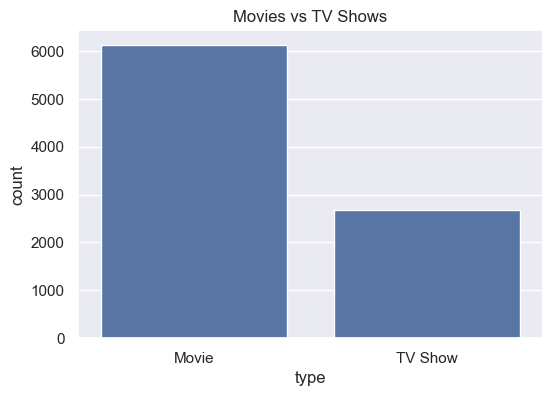

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='type')

plt.title("Movies vs TV Shows")
plt.show()

**Insight:** Movies represent a larger portion of Netflix's content library compared to TV Shows.

### Top Content Producing Countries

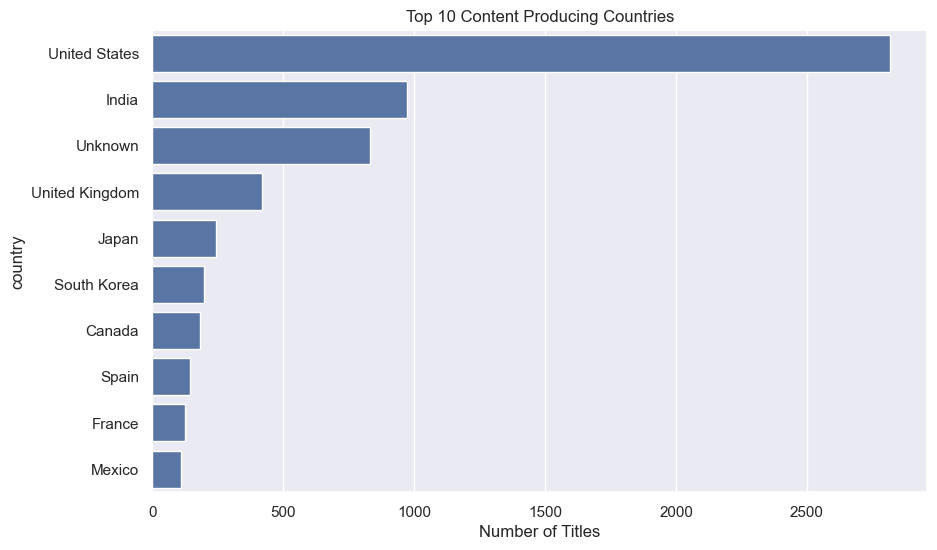

In [17]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Content Producing Countries")
plt.xlabel("Number of Titles")
plt.show()

**Insight:** The United States contributes the highest amount of content to Netflix.

### Genre Analysis

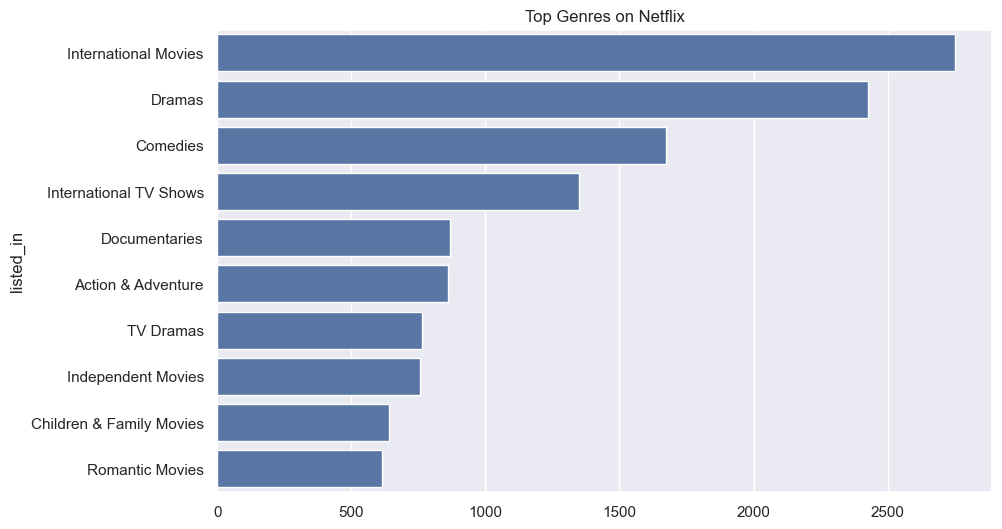

In [18]:
genres = df['listed_in'].str.split(', ').explode()

top_genres = genres.value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top Genres on Netflix")
plt.show()

### Ratings Distribution

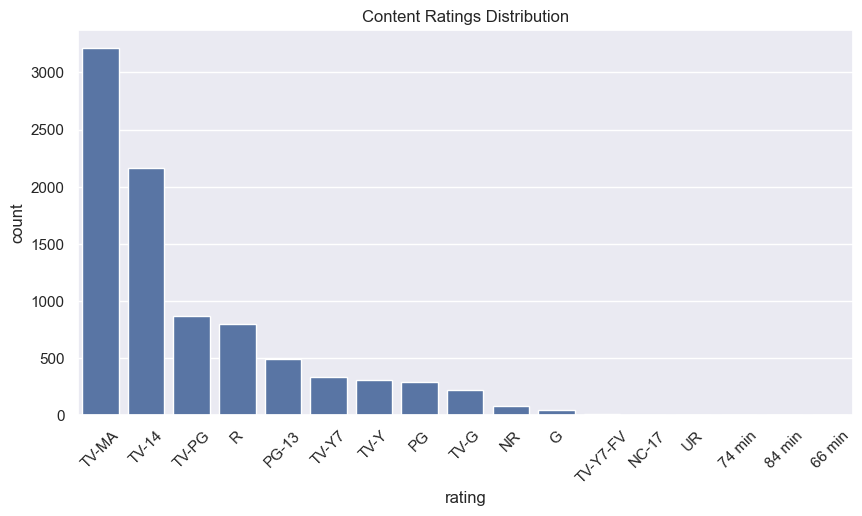

In [19]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='rating',
    order=df['rating'].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Content Ratings Distribution")
plt.show()

### Content Growth Over Time

In [20]:
#Convert Date
df['date_added'] = pd.to_datetime(
    df['date_added'],
    errors='coerce'
)

df['year_added'] = df['date_added'].dt.year

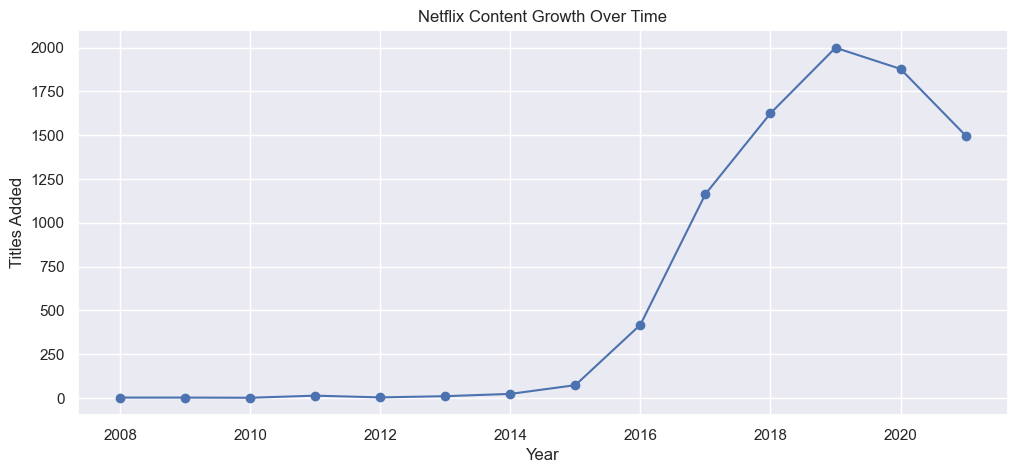

In [21]:
#Plot
content_by_year = (
    df['year_added']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12,5))

plt.plot(
    content_by_year.index,
    content_by_year.values,
    marker='o'
)

plt.title("Netflix Content Growth Over Time")
plt.xlabel("Year")
plt.ylabel("Titles Added")
plt.grid(True)

plt.show()

**Insight:** Netflix experienced significant content growth after 2015.

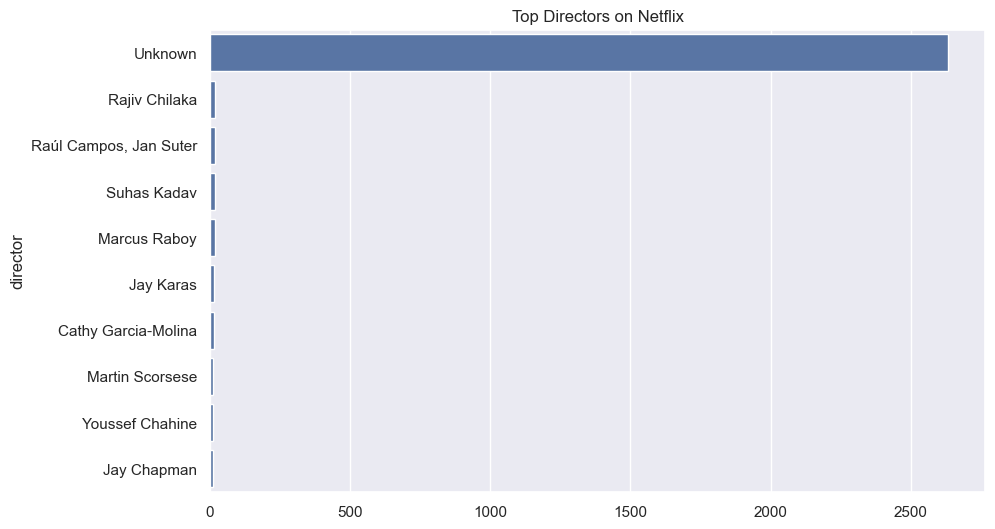

In [22]:
#Top Directors 
top_directors = (
    df['director']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_directors.values,
    y=top_directors.index
)

plt.title("Top Directors on Netflix")
plt.show()

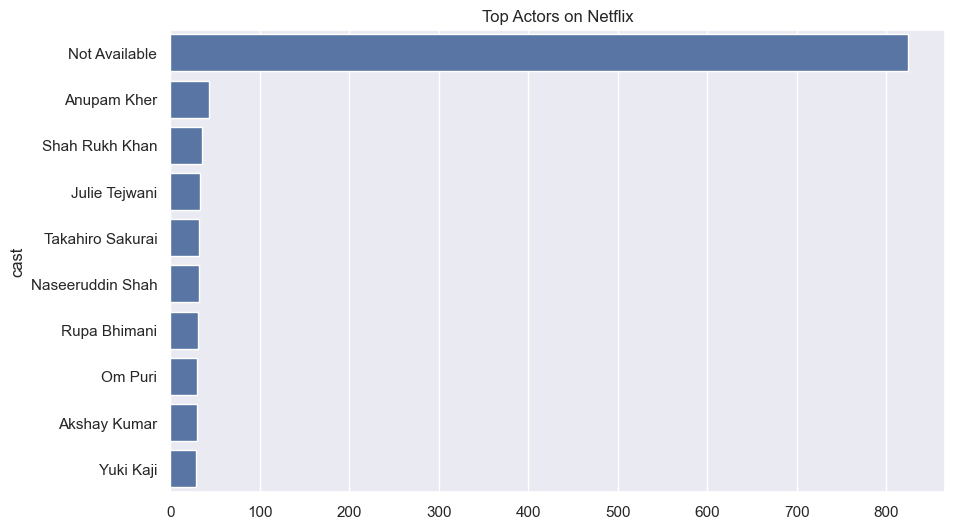

In [23]:
#Top Actors 
actors = df['cast'].str.split(', ').explode()

top_actors = actors.value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_actors.values,
    y=top_actors.index
)

plt.title("Top Actors on Netflix")
plt.show()

### Movie Duration Analysis

<>:5: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:5: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\Ayush Sharma\AppData\Local\Temp\ipykernel_16784\3756024621.py:5: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  .str.extract('(\d+)')


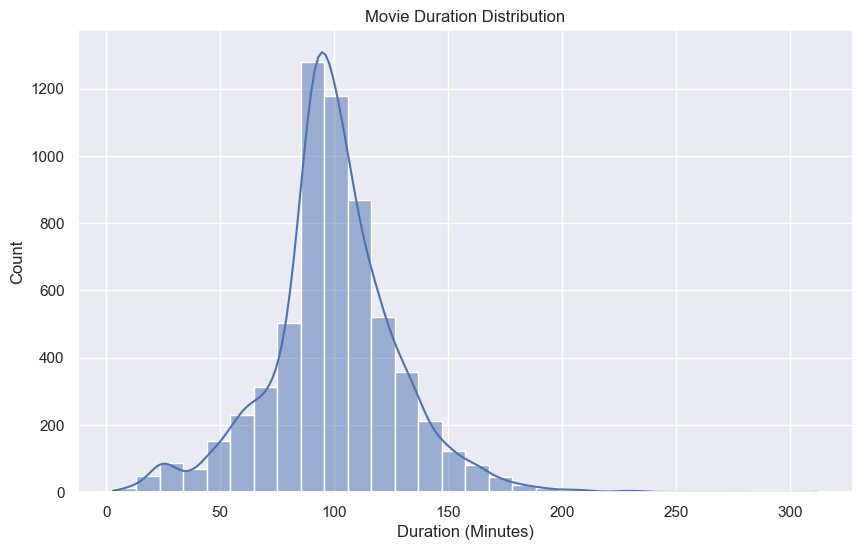

In [26]:
movies = df[df['type'] == 'Movie'].copy()

movies['duration_num'] = (
    movies['duration']
    .str.extract('(\d+)')
)

movies['duration_num'] = pd.to_numeric(
    movies['duration_num']
)
plt.figure(figsize=(10,6))

sns.histplot(
    movies['duration_num'],
    bins=30,
    kde=True
)

plt.title("Movie Duration Distribution")
plt.xlabel("Duration (Minutes)")
plt.show()

## 💡 Key Findings

#### - Movies dominate Netflix's catalog.
#### - The United States is the leading content producer.
#### - Drama and International Movies are highly popular genres.
#### - Netflix's content growth accelerated after 2015.
#### - Most movies range between 80 and 120 minutes.

## 📝 Conclusion

## 📝 Conclusion

##### This project analyzed Netflix's content library using Python, Pandas, Matplotlib, and Seaborn.

#The study highlighted trends in content distribution, genre popularity, ratings, and content growth over time. Through data cleaning, visualization, and exploratory analysis, valuable insights were extracted that help understand Netflix's evolving content strategy.

## 🚀 Future Improvements